<a href="https://colab.research.google.com/github/MiracleQi2000/Text-analysis-workshop_20250401/blob/Tutorial/Workshop3_NLP_0401.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Load data**


In [4]:
import pandas as pd

file_path = 'workshop_reddit_data.json'

df = pd.read_json(file_path, lines=True)

df

,all_awardings,author,author_created_utc,author_flair_background_color,author_flair_css_class,author_flair_richtext,author_flair_template_id,author_flair_text,author_flair_text_color,author_flair_type,...,steward_reports,stickied,subreddit,subreddit_id,subreddit_name_prefixed,subreddit_type,total_awards_received,author_cakeday,awarders,associated_award
0,[],Kinjenti,NaN,None,NaN,[],NaN,NaN,None,text,...,[],False,climatechange,t5_2rawx,r/climatechange,public,0,NaN,[],NaN
1,[],umerca9,1.526639e+09,None,NaN,[],NaN,NaN,None,text,...,[],False,climatechange,t5_2rawx,r/climatechange,public,0,NaN,None,NaN
2,[],[deleted],NaN,,NaN,None,NaN,NaN,dark,None,...,[],False,climatechange,t5_2rawx,r/climatechange,public,0,NaN,[],NaN
3,[],technologyisnatural,1.268630e+09,None,NaN,[],NaN,NaN,None,text,...,[],False,climatechange,t5_2rawx,r/climatechange,public,0,NaN,[],NaN
4,[],[deleted],NaN,,NaN,None,NaN,NaN,dark,None,...,[],False,climatechange,t5_2rawx,r/climatechange,public,0,NaN,[],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,[],BrexitAddict,1.553174e+09,None,NaN,[],NaN,NaN,None,text,...,[],False,climatechange,t5_2rawx,r/climatechange,public,0,NaN,[],NaN
96,[],BrexitAddict,1.553174e+09,None,NaN,[],NaN,NaN,None,text,...,[],False,climatechange,t5_2rawx,r/climatechange,public,0,NaN,[],NaN
97,[],hauntedhivezzz,1.451410e+09,None,NaN,[],NaN,NaN,None,text,...,[],False,climatechange,t5_2rawx,r/climatechange,public,0,NaN,[],NaN
98,[],Will_Power,1.234060e+09,None,NaN,[],NaN,NaN,None,text,...,[],False,climatechange,t5_2rawx,r/climatechange,public,0,NaN,None,NaN


In [5]:
print(df.shape)

(100, 45)


In [6]:
# selcet necessary vairables
df = df[['author', 'author_created_utc', 'subreddit', 'subreddit_id', 'body']]

df.head()

,author,author_created_utc,subreddit,subreddit_id,body
0,Kinjenti,NaN,climatechange,t5_2rawx,Where exactly?
1,umerca9,1.526639e+09,climatechange,t5_2rawx,Isn’t it already way too late. Aren’t we just ...
2,[deleted],NaN,climatechange,t5_2rawx,lol
3,technologyisnatural,1.268630e+09,climatechange,t5_2rawx,The wiki page on the Carbon Cycle has basic es...
4,[deleted],NaN,climatechange,t5_2rawx,"[July 18, 2007:](https://youtu.be/IZ71TqRnxxs)..."


In [7]:
# retain avaiblae data
df = df[df['author'] != '[deleted]']
df = df.dropna()

df.head()

,author,author_created_utc,subreddit,subreddit_id,body
1,umerca9,1.526639e+09,climatechange,t5_2rawx,Isn’t it already way too late. Aren’t we just ...
3,technologyisnatural,1.268630e+09,climatechange,t5_2rawx,The wiki page on the Carbon Cycle has basic es...
5,Will_Power,1.234060e+09,climatechange,t5_2rawx,"You are close, though you miss one crucial poi..."
6,DocHarford,1.488738e+09,climatechange,t5_2rawx,&gt;She has a driving need to work to reverse ...
7,ProgressiveLoading,1.371580e+09,climatechange,t5_2rawx,"They don't specifically mention Biochar, howev..."


In [8]:
import datetime
from datetime import timedelta

# convert UTC time
def convert_to_datetime(utc_timestamp):
    return datetime.datetime.fromtimestamp(utc_timestamp)

# convert author_created_utc variable
df['author_created_utc'] = df['author_created_utc'].apply(convert_to_datetime)

df.head()

,author,author_created_utc,subreddit,subreddit_id,body
1,umerca9,2018-05-18 10:21:14,climatechange,t5_2rawx,Isn’t it already way too late. Aren’t we just ...
3,technologyisnatural,2010-03-15 05:09:05,climatechange,t5_2rawx,The wiki page on the Carbon Cycle has basic es...
5,Will_Power,2009-02-08 02:25:23,climatechange,t5_2rawx,"You are close, though you miss one crucial poi..."
6,DocHarford,2017-03-05 18:16:44,climatechange,t5_2rawx,&gt;She has a driving need to work to reverse ...
7,ProgressiveLoading,2013-06-18 18:26:45,climatechange,t5_2rawx,"They don't specifically mention Biochar, howev..."


In [9]:
print(df.shape)

(82, 5)


**2. Data proprocess**



(1) Text Cleaning

In [10]:
import re
import string
import pandas as pd

def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\W+', ' ', text)  # Remove special characters
    return text.strip()  # Remove leading/trailing whitespace


# Apply the text cleaning function to the 'body' column
df['cleaned_body'] = df['body'].apply(clean_text)

In [11]:
df[['body', 'cleaned_body']].head()

,body,cleaned_body
1,Isn’t it already way too late. Aren’t we just ...,isn t it already way too late aren t we just f...
3,The wiki page on the Carbon Cycle has basic es...,the wiki page on the carbon cycle has basic es...
5,"You are close, though you miss one crucial poi...",you are close though you miss one crucial poin...
6,&gt;She has a driving need to work to reverse ...,gtshe has a driving need to work to reverse cl...
7,"They don't specifically mention Biochar, howev...",they dont specifically mention biochar however...


(2) Tokenization

In [12]:
def tokenization(text):

    # Use \W+ to split on non-word characters
    tokens = re.split(r'\W+', text)

    # Remove empty tokens if any
    return [token for token in tokens if token]

# Apply the tokenization function to cleaned corpus
df['tokenized_body'] = df['cleaned_body'].apply(tokenization)

In [13]:
df['tokenized_body']

,tokenized_body
1,"[isn, t, it, already, way, too, late, aren, t,..."
3,"[the, wiki, page, on, the, carbon, cycle, has,..."
5,"[you, are, close, though, you, miss, one, cruc..."
6,"[gtshe, has, a, driving, need, to, work, to, r..."
7,"[they, dont, specifically, mention, biochar, h..."
...,...
95,"[you, can, learn, more, and, more, about, ever..."
96,"[the, sun, is, causing, the, heat, same, as, a..."
97,"[vs, other, kinds, of, gravity, storage]"
98,"[gtplease, give, me, a, baseline, of, where, y..."


(3) Stop Words Removal

In [14]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Get the stop words
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [85]:
stop_words[0:15]  # Display the first 15 stop words

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't"]

In [15]:
def remove_stopwords(tokens):
    output = [token for token in tokens if token.lower() not in stop_words]
    return output

# Remove the stopwords in the tokenized text
df['no_stopwords_body'] = df['tokenized_body'].apply(remove_stopwords)

In [16]:
df[['tokenized_body', 'no_stopwords_body']]

,tokenized_body,no_stopwords_body
1,"[isn, t, it, already, way, too, late, aren, t,...","[already, way, late, feeling, effects, greenho..."
3,"[the, wiki, page, on, the, carbon, cycle, has,...","[wiki, page, carbon, cycle, basic, estimates, ..."
5,"[you, are, close, though, you, miss, one, cruc...","[close, though, miss, one, crucial, point, inc..."
6,"[gtshe, has, a, driving, need, to, work, to, r...","[gtshe, driving, need, work, reverse, climate,..."
7,"[they, dont, specifically, mention, biochar, h...","[dont, specifically, mention, biochar, however..."
...,...,...
95,"[you, can, learn, more, and, more, about, ever...","[learn, everything, cast, doubt, meantime, doe..."
96,"[the, sun, is, causing, the, heat, same, as, a...","[sun, causing, heat, always, co, makes, heat, ..."
97,"[vs, other, kinds, of, gravity, storage]","[vs, kinds, gravity, storage]"
98,"[gtplease, give, me, a, baseline, of, where, y...","[gtplease, give, baseline, coming, coming, pla..."


(4) Stemming and Lemmatization

In [17]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('wordnet')

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Stemming
df['stemmed_body'] = df['no_stopwords_body'].apply(lambda doc: [stemmer.stem(word) for word in doc])

# Lemmatization
df['lemmatized_body'] = df['no_stopwords_body'].apply(lambda doc: [lemmatizer.lemmatize(word) for word in doc])

# Optional: Specify POS for better lemmatization
def lemmatize_with_pos(doc):
    return [lemmatizer.lemmatize(word, pos='v') for word in doc]  # Example: treating all as verbs

# Apply lemmatization with POS
df['lemmatized_body_with_pos'] = df['no_stopwords_body'].apply(lemmatize_with_pos)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [18]:
df[['no_stopwords_body', 'stemmed_body', 'lemmatized_body', 'lemmatized_body_with_pos']]

,no_stopwords_body,stemmed_body,lemmatized_body,lemmatized_body_with_pos
1,"[already, way, late, feeling, effects, greenho...","[alreadi, way, late, feel, effect, greenhous, ...","[already, way, late, feeling, effect, greenhou...","[already, way, late, feel, effect, greenhouse,..."
3,"[wiki, page, carbon, cycle, basic, estimates, ...","[wiki, page, carbon, cycl, basic, estim, carbo...","[wiki, page, carbon, cycle, basic, estimate, c...","[wiki, page, carbon, cycle, basic, estimate, c..."
5,"[close, though, miss, one, crucial, point, inc...","[close, though, miss, one, crucial, point, inc...","[close, though, miss, one, crucial, point, inc...","[close, though, miss, one, crucial, point, inc..."
6,"[gtshe, driving, need, work, reverse, climate,...","[gtshe, drive, need, work, revers, climat, cha...","[gtshe, driving, need, work, reverse, climate,...","[gtshe, drive, need, work, reverse, climate, c..."
7,"[dont, specifically, mention, biochar, however...","[dont, specif, mention, biochar, howev, indigo...","[dont, specifically, mention, biochar, however...","[dont, specifically, mention, biochar, however..."
...,...,...,...,...
95,"[learn, everything, cast, doubt, meantime, doe...","[learn, everyth, cast, doubt, meantim, doesnt,...","[learn, everything, cast, doubt, meantime, doe...","[learn, everything, cast, doubt, meantime, doe..."
96,"[sun, causing, heat, always, co, makes, heat, ...","[sun, caus, heat, alway, co, make, heat, stick...","[sun, causing, heat, always, co, make, heat, s...","[sun, cause, heat, always, co, make, heat, sti..."
97,"[vs, kinds, gravity, storage]","[vs, kind, graviti, storag]","[v, kind, gravity, storage]","[vs, kinds, gravity, storage]"
98,"[gtplease, give, baseline, coming, coming, pla...","[gtpleas, give, baselin, come, come, place, de...","[gtplease, give, baseline, coming, coming, pla...","[gtplease, give, baseline, come, come, place, ..."


**3. NLP models**


(1) Bag-of-Words

In [19]:
# Using Reddit data
from sklearn.feature_extraction.text import CountVectorizer

# Create an instance of CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the 'cleaned_body' column
X = vectorizer.fit_transform(df['cleaned_body'])

# Get the feature names
feature_names = vectorizer.get_feature_names_out()

# Convert to array
X_array = X.toarray()

# Print the unique words and the Bag of Words matrix
print("Unique Word List: \n", feature_names)
print("Bag of Words Matrix: \n", X_array)

Unique Word List: 
 ['aachen' 'able' 'abohar' ... 'zanskar' 'zero' 'zschokke']
Bag of Words Matrix: 
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [20]:
# Using smapel corpus
from sklearn.feature_extraction.text import CountVectorizer

# Example corpus
corpus = [
    "How is olive oil not healthy? It seems like a great, healthy source of fat.",
    "Did you seriously use a source from a site called \"pewform\". Try again with an unbiased, independent study.",
    "People are dying from Capitalism and greed, not lack of meds. The meds exist in vast quantities, but Capitalism is bad at distribution.",
    "Easy to strengthen climate targets if you are anticipating economic slowdown",
    "I don't have a complete answer on this, but I think some oceans might go through cycles where they emit CO2 part of the time, and absorb it part of the time. I think this is an active topic of research."
]

# Create an instance of CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the corpus
X = vectorizer.fit_transform(corpus)

# Get the feature names
feature_names = vectorizer.get_feature_names_out()

# Convert to array
X_array = X.toarray()

# Print the unique words and the Bag of Words matrix
print("Unique Word List: \n", feature_names)
print("Bag of Words Matrix: \n", X_array)

Unique Word List: 
 ['absorb' 'active' 'again' 'an' 'and' 'answer' 'anticipating' 'are' 'at'
 'bad' 'but' 'called' 'capitalism' 'climate' 'co2' 'complete' 'cycles'
 'did' 'distribution' 'don' 'dying' 'easy' 'economic' 'emit' 'exist' 'fat'
 'from' 'go' 'great' 'greed' 'have' 'healthy' 'how' 'if' 'in'
 'independent' 'is' 'it' 'lack' 'like' 'meds' 'might' 'not' 'oceans' 'of'
 'oil' 'olive' 'on' 'part' 'people' 'pewform' 'quantities' 'research'
 'seems' 'seriously' 'site' 'slowdown' 'some' 'source' 'strengthen'
 'study' 'targets' 'the' 'they' 'think' 'this' 'through' 'time' 'to'
 'topic' 'try' 'unbiased' 'use' 'vast' 'where' 'with' 'you']
Bag of Words Matrix: 
 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 2 1 0 0 0
  1 1 0 1 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1
  1 0 0 1 1]
 [0 0 0 0 1 

(2) Embedding

In [71]:
!pip install fasttext

In [92]:
import pandas as pd
import fasttext

# change the no_stopword_body into string
def remove_stopwords(tokens):
    stop_words = set(stopwords.words('english'))
    # Filter out the stopwords from the tokenized list
    filtered_tokens = [token for token in tokens if token not in stop_words]
    return ' '.join(filtered_tokens)  # Return as a single string

# Remove the stopwords in the tokenized text
df['no_stopwords_body_str'] = df['tokenized_body'].apply(remove_stopwords)

# Save the tokenized sentences to a text file for fastText
with open('sentences.txt', 'w') as f:
    for sentence in df['no_stopwords_body_str']:
        f.write(sentence + '\n')

# Train the fastText model
model = fasttext.train_unsupervised('sentences.txt', model='skipgram')

In [93]:
# Example: Get the word vector for a word
word_vector = model.get_word_vector('document')
print("Embedding for 'document':", word_vector)

Embedding for 'document': [ 7.71537516e-03  1.46798035e-02 -1.02164019e-02 -1.53421238e-03
  3.15787760e-03 -5.87909063e-03 -1.28016463e-02  1.58601627e-02
  1.39726494e-02  5.57111437e-03  2.31368328e-03  2.11976040e-02
  1.12397671e-02  6.79050013e-03 -3.32896365e-03  1.49630790e-03
  1.17542443e-03  9.62659065e-03 -3.97797674e-03 -8.80432315e-03
  1.14011737e-02 -1.23016571e-03  3.19829863e-03 -6.34051254e-03
  3.17961164e-03 -6.45477278e-03  1.75493967e-03 -3.83632560e-03
 -1.10737151e-02  2.89487615e-02 -1.03669465e-02 -8.95465165e-03
 -4.51433379e-03 -2.31933352e-02 -9.70260007e-05 -2.01466633e-03
  2.09319894e-03 -1.87257528e-02 -4.65712836e-03 -2.53602338e-04
  9.22550168e-03  2.06047278e-02  6.22796069e-04  8.08374863e-03
  5.65393828e-04 -4.83713811e-03  8.98031797e-03  7.90172815e-03
  2.08561196e-05  9.11893696e-03 -1.60286389e-02  2.05736104e-02
 -4.03959565e-02  1.48196658e-02  5.32057275e-05 -1.34689650e-02
 -1.21681588e-02  9.64333955e-03  1.08134048e-02  1.34843001e-02

In [94]:
# Example: Find the most similar words to 'document' (only the top 10)
similar_words = model.get_nearest_neighbors('document', k=10)
similar_words

[(0.9994860291481018, 'current'),
 (0.9994807243347168, 'environmental'),
 (0.9994602799415588, 'close'),
 (0.9994583129882812, 'scientists'),
 (0.9994385838508606, 'would'),
 (0.9994338154792786, 'risks'),
 (0.9994319677352905, 'like'),
 (0.999430775642395, 'local'),
 (0.9994303584098816, 'another'),
 (0.9994300007820129, 'science')]

**4. Application**

(1) Sentiment analysis

In [104]:
import nltk
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('vader_lexicon')

# Initialize SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [105]:
# Function to analyze sentiment using TextBlob
def analyze_sentiment_score(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity  # Returns a value between -1 (negative) and 1 (positive)

# Function to analyze sentiment using SentimentIntensityAnalyzer
def analyze_sentiment_sia(text):
    return sia.polarity_scores(text)  # Returns a dictionary with scores

# Apply the sentiment functions on the cleaned_body column
df['sentiment_score'] = df['cleaned_body'].apply(analyze_sentiment_score)
df['sentiment_sia'] = df['cleaned_body'].apply(analyze_sentiment_sia)


# Create sentiment_category based on sentiment_textblob
def categorize_sentiment(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

In [106]:
df[['cleaned_body', 'sentiment_score', 'sentiment_category', 'sentiment_sia']]

,cleaned_body,sentiment_score,sentiment_category,sentiment_sia
1,isn t it already way too late aren t we just f...,-0.450000,negative,"{'neg': 0.147, 'neu': 0.733, 'pos': 0.12, 'com..."
3,the wiki page on the carbon cycle has basic es...,0.000000,neutral,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."
5,you are close though you miss one crucial poin...,0.025000,positive,"{'neg': 0.079, 'neu': 0.868, 'pos': 0.053, 'co..."
6,gtshe has a driving need to work to reverse cl...,0.186051,positive,"{'neg': 0.075, 'neu': 0.802, 'pos': 0.124, 'co..."
7,they dont specifically mention biochar however...,0.076496,positive,"{'neg': 0.026, 'neu': 0.92, 'pos': 0.054, 'com..."
...,...,...,...,...
95,you can learn more and more about everything a...,0.235714,positive,"{'neg': 0.168, 'neu': 0.799, 'pos': 0.034, 'co..."
96,the sun is causing the heat same as always the...,0.000000,neutral,"{'neg': 0.0, 'neu': 0.898, 'pos': 0.102, 'comp..."
97,vs other kinds of gravity storage,-0.125000,negative,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."
98,gtplease give me a baseline of where you are c...,0.011772,positive,"{'neg': 0.066, 'neu': 0.867, 'pos': 0.067, 'co..."


In [107]:
# More text features
from collections import Counter

# Count frequency of words directly from the tokenized lists
word_counts = Counter(word for sublist in df['no_stopwords_body'] for word in sublist)

# Get the 50 most common words
most_common_words = word_counts.most_common(100)

# Extract positive, negative, and neutral words
positive_words = []
negative_words = []
neutral_words = []

for word, count in most_common_words:
    compound_score = sia.polarity_scores(word)['compound']
    if compound_score > 0:
        positive_words.append((word, count))
    elif compound_score < 0:
        negative_words.append((word, count))
    else:
        neutral_words.append((word, count))


In [108]:
positive_words

[('like', 12),
 ('warming', 10),
 ('energy', 10),
 ('natural', 8),
 ('sure', 8),
 ('good', 7),
 ('better', 6),
 ('increased', 5),
 ('great', 5),
 ('gt', 5)]

In [109]:
negative_words

[('bad', 6), ('risks', 5)]

In [110]:
neutral_words

[('people', 30),
 ('dont', 20),
 ('would', 18),
 ('climate', 17),
 ('one', 16),
 ('co', 15),
 ('science', 15),
 ('emissions', 14),
 ('change', 14),
 ('biochar', 13),
 ('think', 12),
 ('say', 11),
 ('far', 11),
 ('much', 11),
 ('et', 11),
 ('al', 11),
 ('time', 11),
 ('know', 10),
 ('carbon', 9),
 ('fact', 9),
 ('water', 9),
 ('even', 9),
 ('also', 9),
 ('global', 9),
 ('find', 9),
 ('get', 9),
 ('scientific', 9),
 ('c', 9),
 ('need', 8),
 ('actually', 8),
 ('environmental', 8),
 ('many', 8),
 ('back', 8),
 ('right', 8),
 ('thats', 8),
 ('something', 8),
 ('nothing', 8),
 ('really', 8),
 ('power', 8),
 ('data', 8),
 ('believe', 8),
 ('level', 7),
 ('population', 7),
 ('going', 7),
 ('might', 7),
 ('rate', 7),
 ('temperature', 7),
 ('since', 6),
 ('close', 6),
 ('century', 6),
 ('isnt', 6),
 ('current', 6),
 ('start', 6),
 ('look', 6),
 ('rise', 6),
 ('likely', 6),
 ('total', 6),
 ('land', 6),
 ('area', 6),
 ('earth', 6),
 ('always', 6),
 ('lot', 6),
 ('show', 6),
 ('still', 6),
 ('rcp',

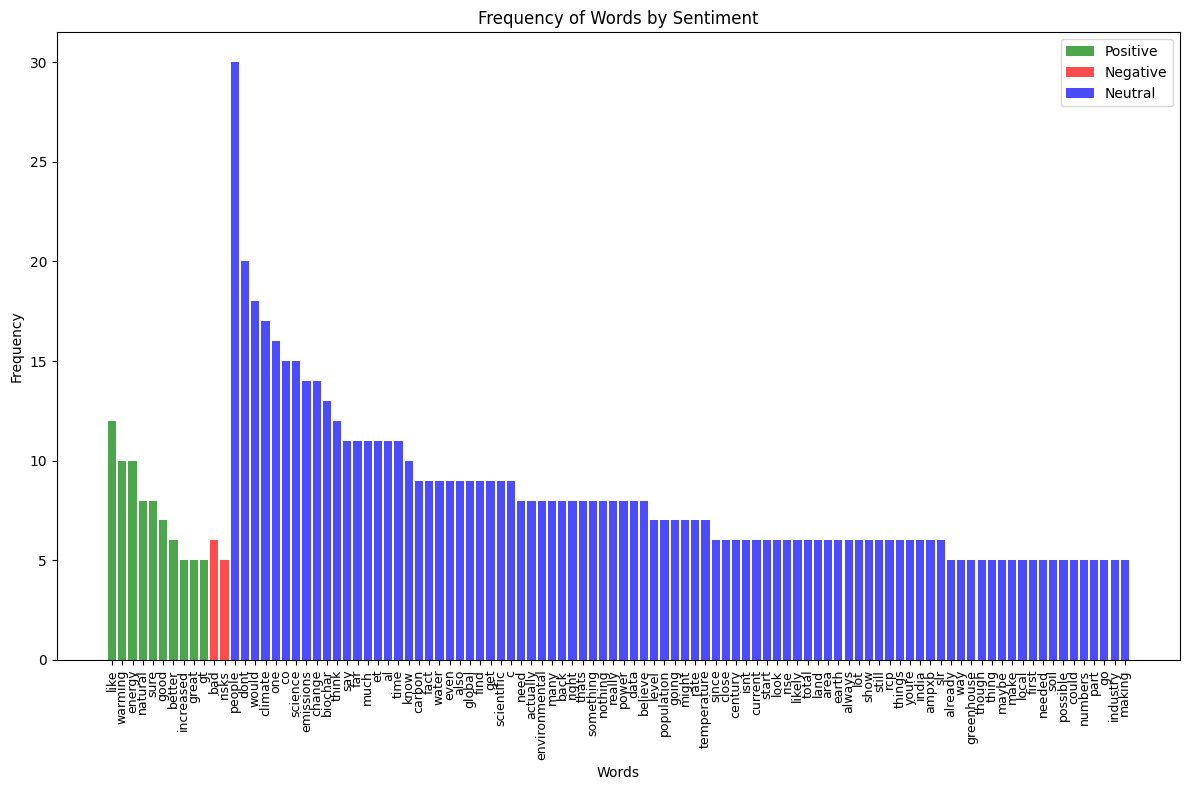

In [111]:
import matplotlib.pyplot as plt

# Prepare data for plotting
positive_words_list = [word for word, count in positive_words]
positive_counts = [count for word, count in positive_words]

negative_words_list = [word for word, count in negative_words]
negative_counts = [count for word, count in negative_words]

neutral_words_list = [word for word, count in neutral_words]
neutral_counts = [count for word, count in neutral_words]

# Set the figure size
plt.figure(figsize=(12, 8))

# Plotting positive words
plt.bar(positive_words_list, positive_counts, color='green', alpha=0.7, label='Positive')

# Plotting negative words
plt.bar(negative_words_list, negative_counts, color='red', alpha=0.7, label='Negative')

# Plotting neutral words
plt.bar(neutral_words_list, neutral_counts, color='blue', alpha=0.7, label='Neutral')

# Adding labels and title
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Frequency of Words by Sentiment')
plt.xticks(rotation=90, fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

(2) Use BERT to extract toxicity level

In [117]:
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
!pip install transformers==4.26.1

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu113
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 1.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 3.4.1 requires transformers<5.0.0,>=4.41.0, which is not installed.
peft 0.14.0 requires transformers, which is not installed.


  Using cached transformers-4.26.1-py3-none-any.whl.metadata (100 kB)
Using cached transformers-4.26.1-py3-none-any.whl (6.3 MB)
ERROR: Operation cancelled by user
^C


In [1]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Load the pre-trained model and tokenizer
model_name = "unitary/toxic-bert"  # A BERT model for toxicity classification
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Set the model to evaluation mode
model.eval()

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


Moving 0 files to the new cache system


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


0it [00:00, ?it/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [2]:
def predict_toxicity(text):
    # Encode the input text
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # Get model output
    with torch.no_grad():
        outputs = model(**inputs)

    # Get logits
    logits = outputs.logits

    # Calculate toxicity score
    probabilities = torch.sigmoid(logits)  # Use sigmoid to get probabilities
    return probabilities[0][1].item()  # Get toxicity score (second class)


In [21]:
# Calculate toxicity scores for each entry in cleaned_body
df['toxicity_score'] = df['cleaned_body'].apply(predict_toxicity)

# Display the DataFrame with toxicity scores
df[['cleaned_body', 'toxicity_score']]

,cleaned_body,toxicity_score
1,isn t it already way too late aren t we just f...,0.037401
3,the wiki page on the carbon cycle has basic es...,0.000106
5,you are close though you miss one crucial poin...,0.000115
6,gtshe has a driving need to work to reverse cl...,0.000119
7,they dont specifically mention biochar however...,0.000103
...,...,...
95,you can learn more and more about everything a...,0.000097
96,the sun is causing the heat same as always the...,0.000103
97,vs other kinds of gravity storage,0.000124
98,gtplease give me a baseline of where you are c...,0.000102


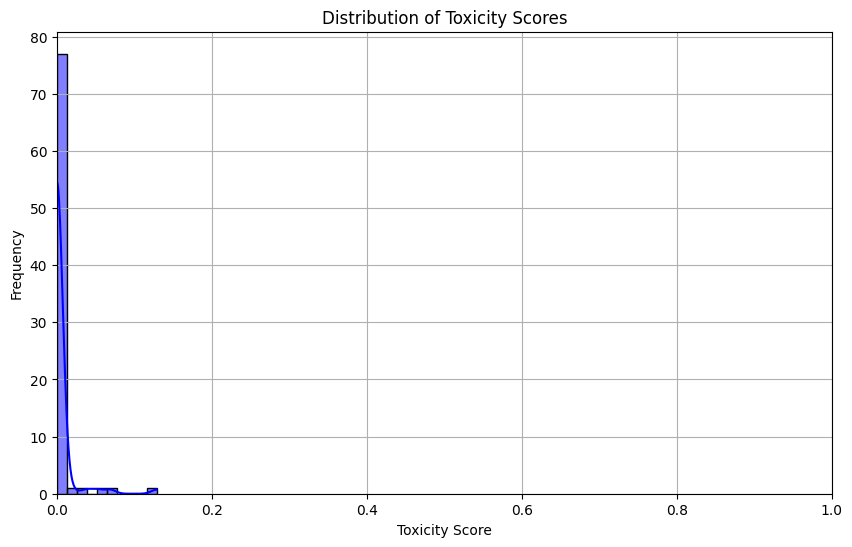

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of toxicity scores
plt.figure(figsize=(10, 6))
sns.histplot(df['toxicity_score'], bins=10, kde=True, color='blue')
plt.title('Distribution of Toxicity Scores')
plt.xlabel('Toxicity Score')
plt.ylabel('Frequency')
plt.xlim(0, 1)  # Toxicity scores range from 0 to 1
plt.grid(True)
plt.show()